In [3]:
!pip install alibi

In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
import matplotlib.pyplot as plt

df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
df = df.drop_duplicates().dropna()

X = df.drop(columns=["Diabetes_012"])
y = df["Diabetes_012"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
estimators = [
    ('xgb', XGBClassifier(
        random_state=42,
        learning_rate=0.05,
        n_estimators=300,
        max_depth=7,
        subsample=0.7,
        colsample_bytree=0.7
    )),
    ('knn', KNeighborsClassifier())
]

model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=42),
    cv=5
)
model.fit(X_train, y_train)
print("Accuracy score:", accuracy_score(y_test, model.predict(X_test)))

Accuracy score: 0.8351937680875601


In [10]:
from sklearn.inspection import permutation_importance

X_test_sampled, _, y_test_sampled, _ = train_test_split(X_test, y_test, test_size=0.9, random_state=42, stratify=y_test)

all_feature_names = X.columns
perm_importance = permutation_importance(model, X_test_sampled, y_test_sampled, n_repeats=2, random_state=42, n_jobs=-1)

perm_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
})
perm_importance_df = perm_importance_df.sort_values(by='importance', ascending=False)
display(perm_importance_df)

,feature,importance,std
3,BMI,9.902067e-03,0.001415
13,GenHlth,4.461371e-03,0.003373
14,MentHlth,2.067465e-03,0.000979
20,Income,1.849837e-03,0.000979
4,Smoker,1.741023e-03,0.000218
1,HighChol,1.741023e-03,0.000435
16,DiffWalk,1.414581e-03,0.000979
10,HvyAlcoholConsump,1.196953e-03,0.000326
8,Fruits,9.793254e-04,0.000326
12,NoDocbcCost,8.705114e-04,0.000218


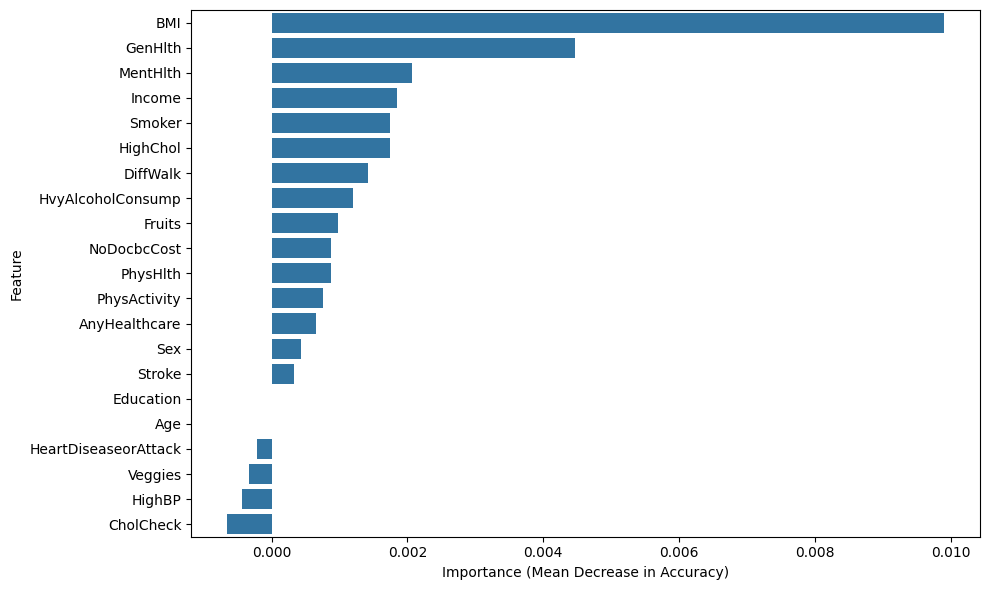

In [11]:
import seaborn as sns
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=perm_importance_df)
plt.xlabel('Importance (Mean Decrease in Accuracy)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [12]:
from alibi.explainers import ALE
from sklearn.inspection import PartialDependenceDisplay

top_5_features = perm_importance_df.head(5)['feature'].tolist()
print(f"Top 5 important features: {top_5_features}")

Top 5 important features: ['BMI', 'GenHlth', 'MentHlth', 'Income', 'Smoker']


Generating ALE plot for BMI


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Generating ALE plot for GenHlth


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Generating ALE plot for MentHlth


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Generating ALE plot for Income


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Generating ALE plot for Smoker


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


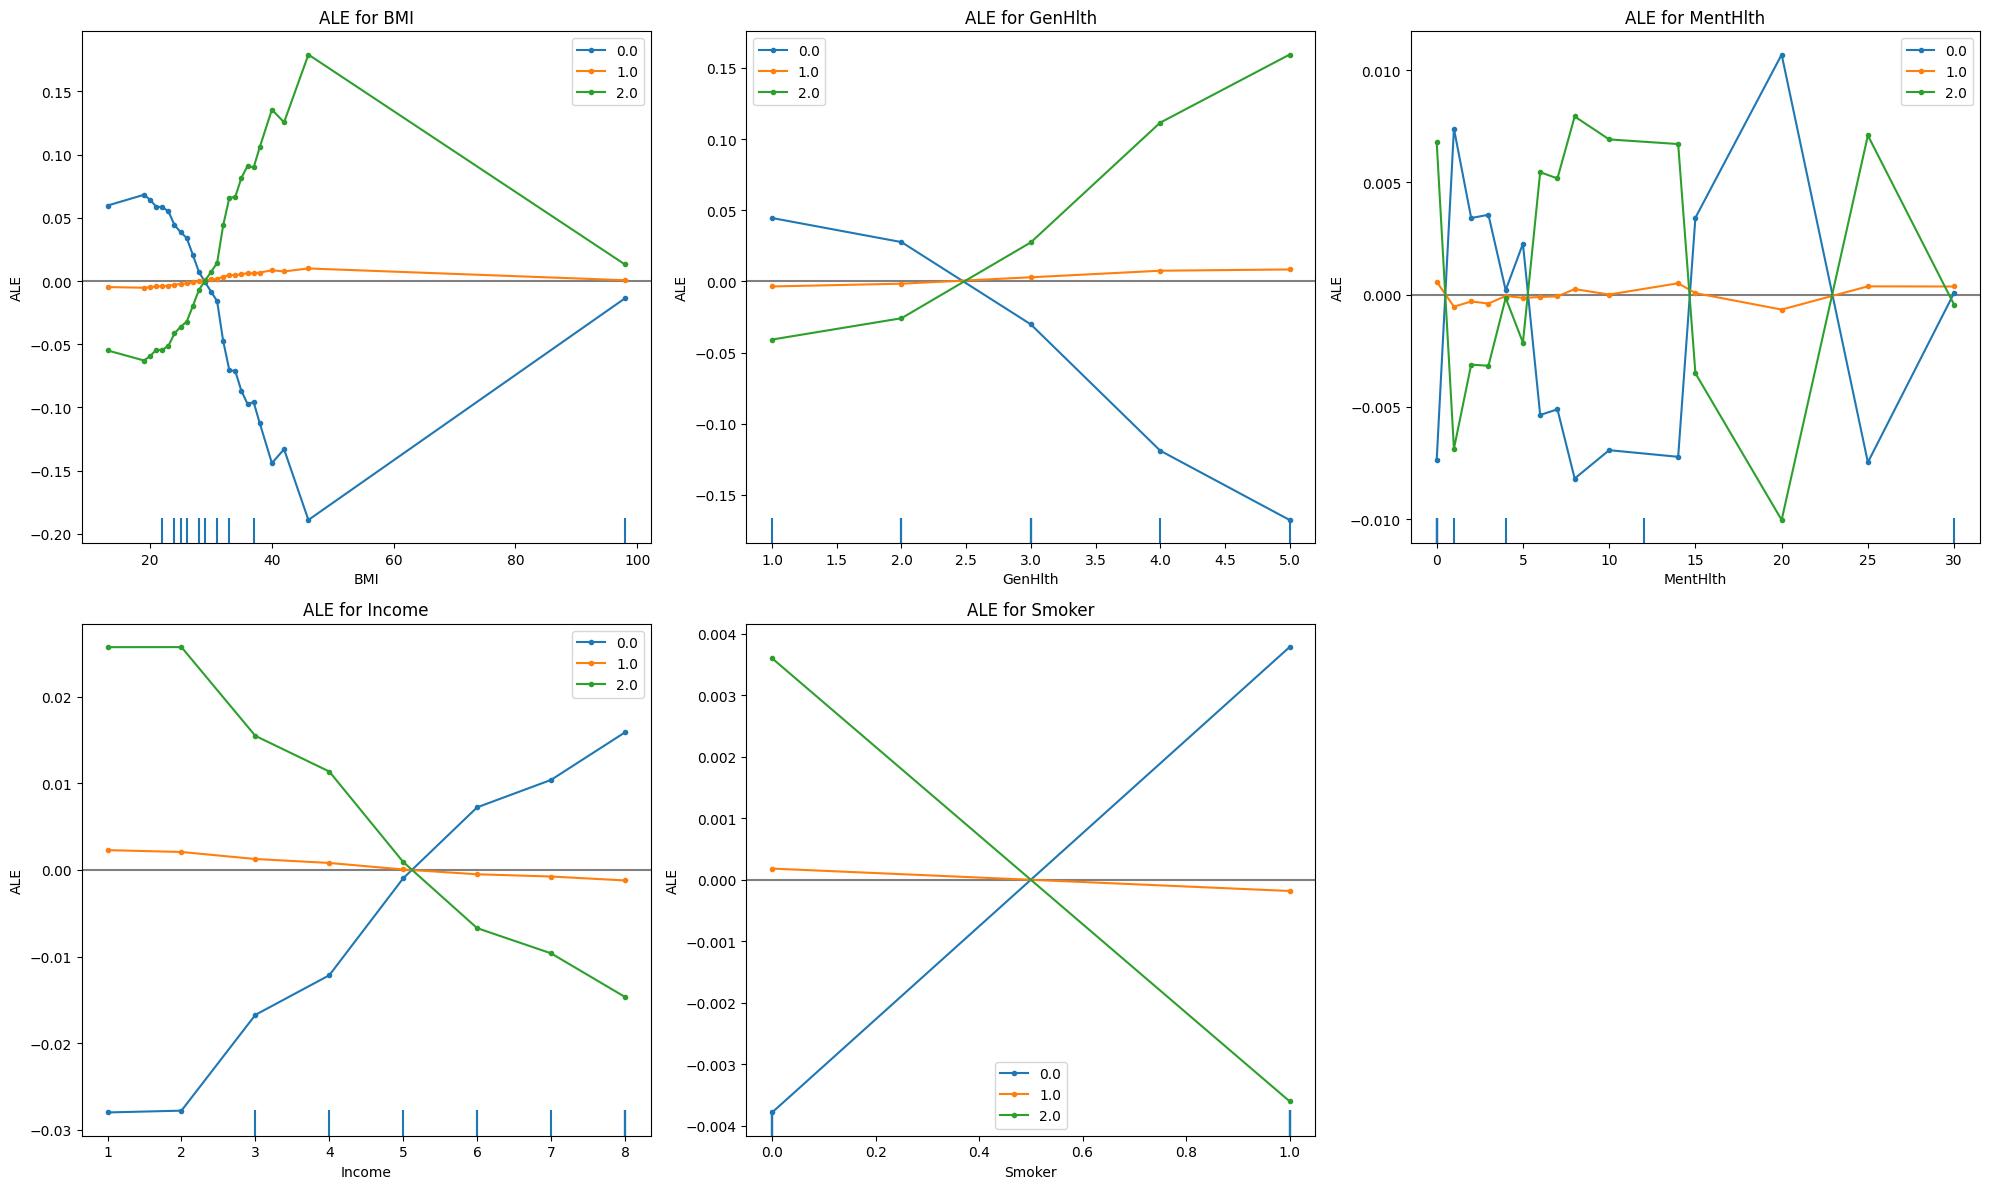

In [26]:
import matplotlib.pyplot as plt
from alibi.explainers import ALE
from alibi.explainers.ale import plot_ale

ale_explainer = ALE(predictor=model.predict_proba, feature_names=X.columns.tolist(),
                    target_names=[str(c) for c in model.classes_]) # Convert classes to string for target_names

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
axes = axes.flatten()


for i, feature in enumerate(top_5_features):
    print(f"Generating ALE plot for {feature}")
    feature_idx_global = X.columns.get_loc(feature)
    explanation = ale_explainer.explain(X_test_sampled.values, features=[feature_idx_global])

    current_ax = axes[i]
    plot_ale(explanation, ax=current_ax)
    current_ax.set_title(f'ALE for {feature}')
for j in range(len(top_5_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Generating PDP and ICE plots for BMI


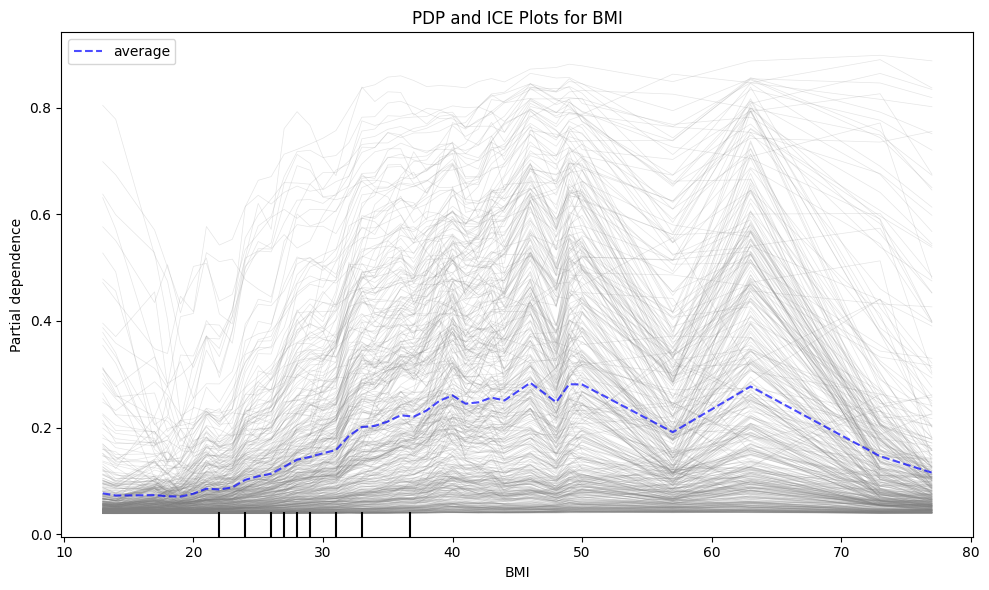

Generating PDP and ICE plots for GenHlth


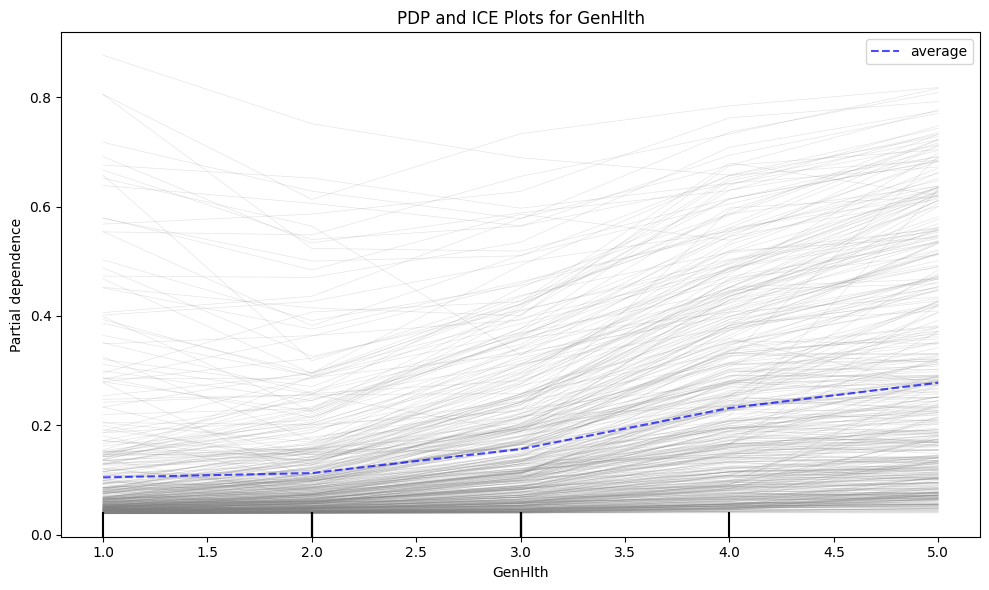

Generating PDP and ICE plots for MentHlth


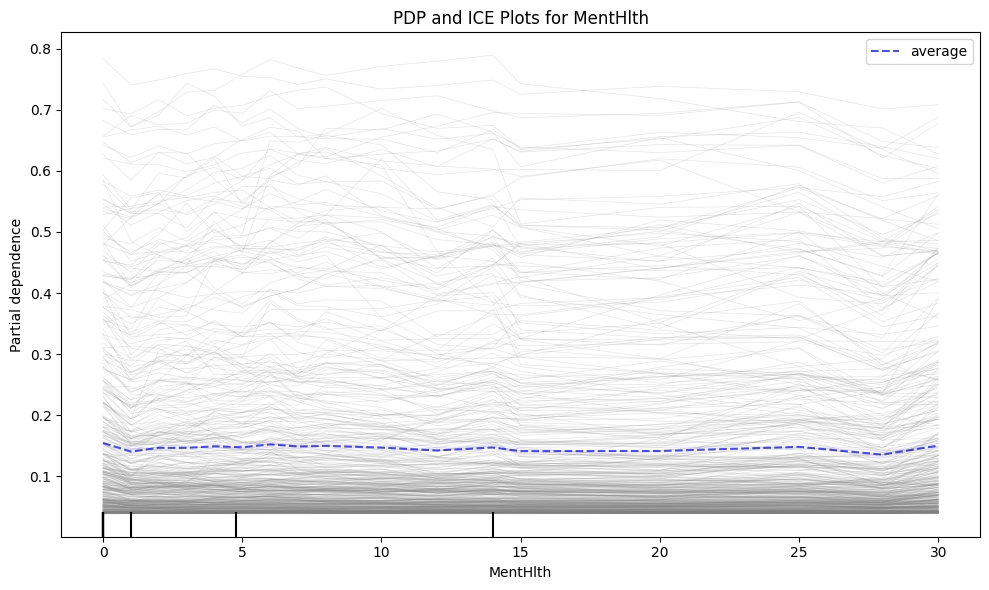

Generating PDP and ICE plots for Income


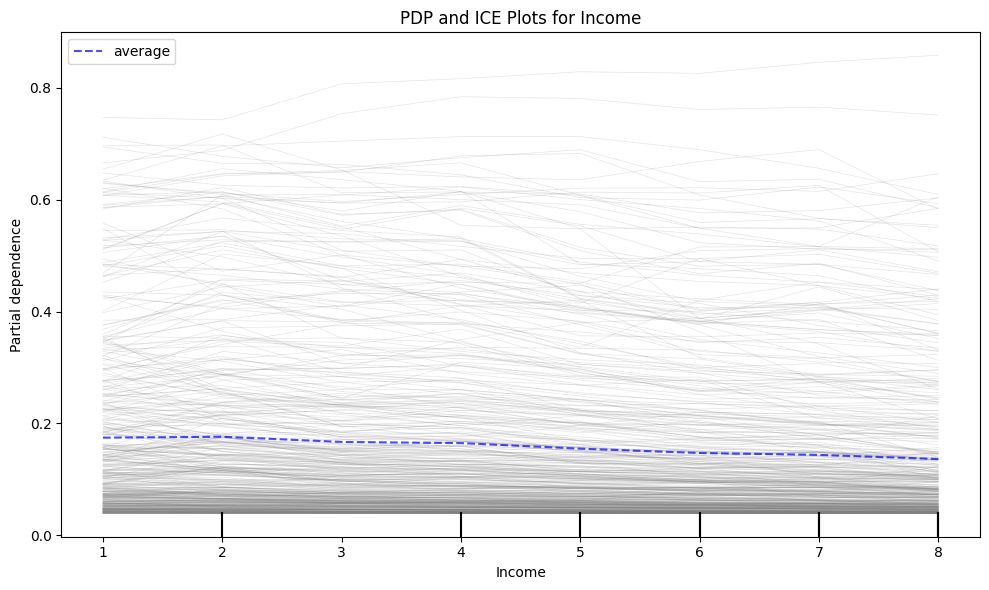

Generating PDP and ICE plots for Smoker


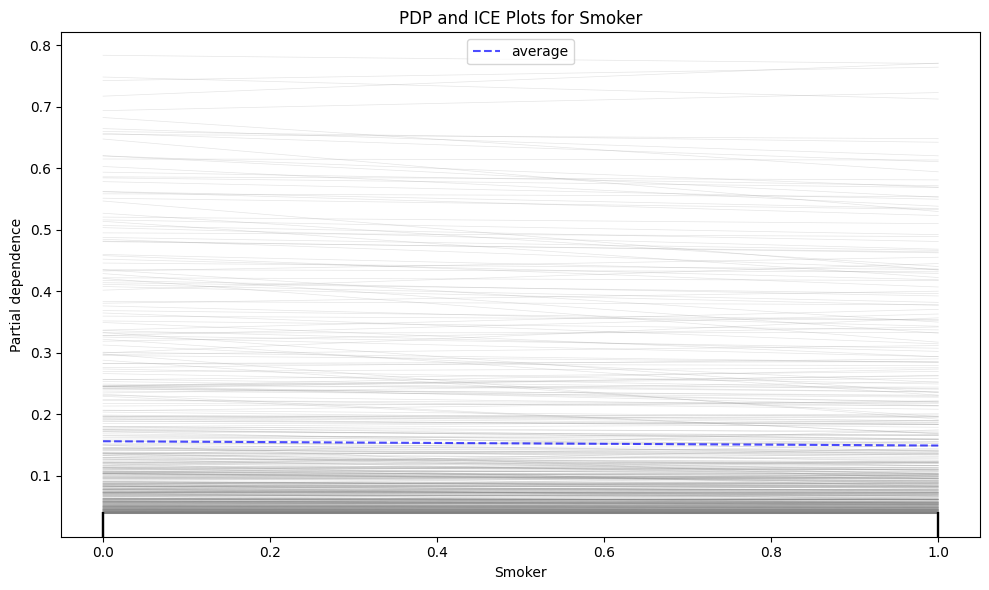

In [25]:
from sklearn.model_selection import train_test_split
X_plot_sampled, _, _, _ = train_test_split(X_test_sampled, y_test_sampled, test_size=0.9, random_state=42, stratify=y_test_sampled)

for feature in top_5_features:
    print(f"Generating PDP and ICE plots for {feature}")
    fig, ax = plt.subplots(figsize=(10, 6))
    PartialDependenceDisplay.from_estimator(model, X_plot_sampled, features=[feature], kind='both', ax=ax, line_kw={'color': 'blue', 'alpha': 0.7}, ice_lines_kw={'color': 'gray', 'alpha': 0.2}, target=2)
    ax.set_title(f'PDP and ICE Plots for {feature}')
    plt.tight_layout()
    plt.show()